In [1]:
import pypsa
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import geopandas as gpd
import pandas as pd
import os
# Line2D
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm


In [2]:
TITLE_SIZE = 20

In [143]:
# BAU
n_lr_reactive = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_cl33a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc')
n_lr_proactive = pypsa.Network("/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_cl33a_ch300a_ec_lvopt_REM-4h_E_mapped_TEP.nc")

n_hr_reactive = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_cl300a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc')
n_hr_proactive = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_c300a_ec_lvopt_REM-4h_E.nc')

INFO:pypsa.io:Imported network elec_s310_cl33a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network elec_s310_cl33a_ch300a_ec_lvopt_REM-4h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network elec_s310_cl300a_ch300a_ec_lv1.0_REM-4h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network elec_s310_c300a_ec_lvopt_REM-4h_E.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [144]:
n_lr_reactive.carriers.at['imports','color'] = '#DADADA'
n_lr_proactive.carriers.at['imports','color'] = '#DADADA'
n_hr_reactive.carriers.at['imports','color'] = '#DADADA'
n_hr_proactive.carriers.at['imports','color'] = '#DADADA'
n_hr_reactive.carriers

,co2_emissions,color,nice_name,max_growth,max_relative_growth
Carrier,,,,,
offwind_floating,0.00000,#11a1c1,Floating Offshore Wind,inf,0.0
solar,0.00000,#f9d002,Solar,inf,0.0
hydro,0.00000,#08ad97,Reservoir & Dam,inf,0.0
onwind,0.00000,#235ebc,Onshore Wind,inf,0.0
oil,0.34900,#262626,Oil,inf,0.0
CCGT-95CCS,0.00905,#800000,Ccgt-95Ccs,inf,0.0
hydrogen_ct,0.00000,#ea048a,Hydrogen Combustion Turbine,inf,0.0
geothermal,0.04000,#ba91b1,Geothermal,inf,0.0
CCGT,0.18100,#b20101,Combined-Cycle Gas,inf,0.0


In [145]:
# # REM
# n_hr_reactive = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/REM/elec_s210_cl180a_ch180a_ec_lv1.0_REM-PRM-3h_E_mapped_TEP.nc')
# n_lr_reactive = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/REM/elec_s210_cl7a_ch180a_ec_lv1.0_REM-PRM-3h_E_mapped_TEP.nc')
# n_lr_proactive = pypsa.Network("/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/REM/elec_s210_cl7a_ch180a_ec_lvopt_REM-PRM-3h_E_mapped_TEP.nc")
# n_hr_proactive = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/REM/elec_s210_c180a_ec_lvopt_REM-PRM-3h_E.nc')

In [160]:
regions_path = os.path.join('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/regions_onshore_s310_300a.geojson')
regions = gpd.read_file(regions_path)
regions_lr = gpd.read_file('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/regions_onshore_s310_33a.geojson')

In [161]:
def plot_capacity_map(
    n: pypsa.Network,
    bus_values: pd.DataFrame,
    line_values: pd.DataFrame,
    link_values: pd.DataFrame,
    regions: gpd.GeoDataFrame,
    ax: plt.axes,
    bus_scale=1,
    line_scale=1,
    title=None,
    flow=None,
    line_colors="teal",
    link_colors="green",
    line_cmap="viridis",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=False,
) -> plt.axes:
    """Generic network plotting function for capacity pie charts at each node."""
    line_width = line_values / line_scale
    link_width = link_values / line_scale

    with plt.rc_context({"patch.linewidth": 0.1}):
        n.plot(
            bus_sizes=bus_values / bus_scale,
            bus_colors=n.carriers.color,
            bus_alpha=0.7,
            line_widths=line_width,
            link_widths=0 if link_width.empty else link_width,
            line_colors=line_colors,
            link_colors=link_colors,
            ax=ax,
            margin=0.2,
            color_geomap=True,
            flow=flow,
            line_cmap=line_cmap,
            line_norm=line_norm,
            line_alpha=line_alpha,
            bus_split_circles=bus_split_circles,
        )

    # onshore regions
    regions.boundary.plot(
        ax=ax,
        facecolor="gainsboro",
        edgecolor="white",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=1.2,
    )
    ax.set_extent(regions.total_bounds[[0, 2, 1, 3]])

    ax.set_title(title or "Capacity (MW)", fontsize=TITLE_SIZE, pad=20)

    return ax


def plot_network_capacity(
    n: pypsa.Network,
    ax: plt.axes,
    regions: gpd.GeoDataFrame,
    plot_type: str = "base",
    bus_scale: float = 1e3,
    line_scale: float = 1e6,
    line_colors: str ="teal",
    link_colors: str="green",
    line_alpha: float = 0.5,
) -> plt.axes:
    """Plot network capacity for buses, lines, and links.".
    
    Options for plot_type:
    - base: Base network capacities
    - opt: Optimal network capacities
    - new: New network capacities
    """
    groupers = n.statistics.groupers

    if plot_type == "base":
        bus_groups = n.statistics.installed_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_groups = bus_groups[bus_groups.index.get_level_values('component') != 'Line']
        bus_groups = bus_groups.droplevel(0)
        bus_values= bus_groups[n.investment_periods[0]]

        line_values = n.lines.s_nom
        link_values = n.links[n.links.carrier == "AC"].p_nom.replace(to_replace={pd.NA: 0})
        title = "Base Network Capacities"
    
    elif plot_type == "opt":
        bus_groups = n.statistics.optimal_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_groups = bus_groups[bus_groups.index.get_level_values('component') != 'Line']
        bus_groups = bus_groups.droplevel(0)
        bus_values= bus_groups[n.investment_periods[0]]

        line_values = n.lines.s_nom_opt
        link_values = n.links[n.links.carrier == "AC"].p_nom_opt.replace(to_replace={pd.NA: 0})
        title = "Optimal Network Capacities"
    
    elif plot_type == "new":
        bus_pnom = n.statistics.installed_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_pnom = bus_pnom[bus_pnom.index.get_level_values('component') != 'Line']
        bus_pnom = bus_pnom.droplevel(0)


        bus_pnom_opt = n.statistics.optimal_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_pnom_opt = bus_pnom_opt[bus_pnom_opt.index.get_level_values('component') != 'Line']
        bus_pnom_opt = bus_pnom_opt.droplevel(0)

        bus_values = bus_pnom_opt - bus_pnom
        bus_values = bus_values[(bus_values > 0)]
        bus_values= bus_values[n.investment_periods[0]]

        
        line_values = n.lines.s_nom_opt - n.lines.s_nom
        link_pnom = n.links[n.links.carrier == "AC"].p_nom
        link_pnom_opt = n.links[n.links.carrier == "AC"].p_nom_opt
        link_values = link_pnom_opt - link_pnom
        link_values = link_values.replace(to_replace={pd.NA: 0})
        title = "New Network Capacities"
    
    else:
        raise ValueError(f"Unknown plot_type: {plot_type}")

    # Plot data
    plot_capacity_map(
        n=n,
        bus_values=bus_values,
        line_values=line_values,
        link_values=link_values,
        regions=regions,
        ax=ax,
        line_scale=line_scale,
        bus_scale=bus_scale,
        title=title,
        line_colors=line_colors,
        link_colors=link_colors,
        line_alpha=line_alpha,
    )
    return ax

# Transmission Comparisons

In [162]:
def get_diff_capacities(n: pypsa.Network):
    groupers = n.statistics.groupers
    bus_pnom = n.statistics.installed_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
    bus_pnom = bus_pnom[bus_pnom.index.get_level_values('component') != 'Line']
    bus_pnom = bus_pnom.droplevel(0)


    bus_pnom_opt = n.statistics.optimal_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
    bus_pnom_opt = bus_pnom_opt[bus_pnom_opt.index.get_level_values('component') != 'Line']
    bus_pnom_opt = bus_pnom_opt.droplevel(0)

    bus_values = bus_pnom_opt.fillna(0) - bus_pnom.fillna(0)
    bus_values= bus_values[n.investment_periods[0]]


    line_values = n.lines.s_nom_opt - n.lines.s_nom
    link_pnom = n.links[n.links.carrier == "AC"].p_nom
    link_pnom_opt = n.links[n.links.carrier == "AC"].p_nom_opt
    link_values = link_pnom_opt - link_pnom
    link_values = link_values.replace(to_replace={pd.NA: 0})
    return bus_values, line_values, link_values


## Low-Res Reactive vs. High-Res Proactive

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

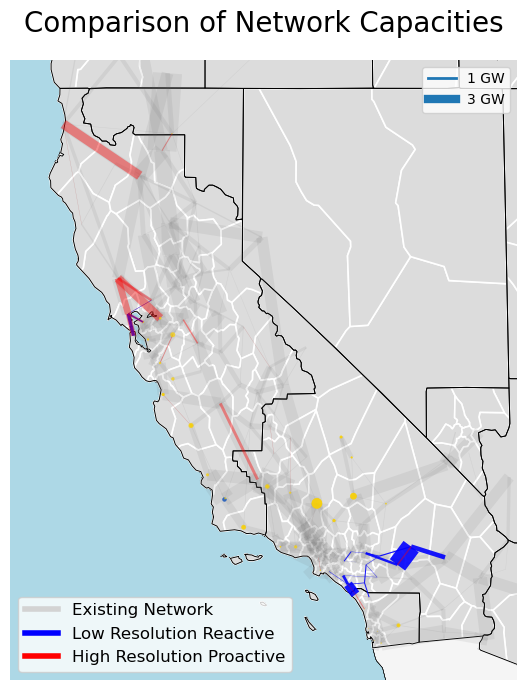

In [195]:
fig, axes = plt.subplots(1, 1, figsize=(7 , 7), subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})

line_scale = 5e2
bus_scale = 1e6

plot_network_capacity(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    plot_type='base',
    bus_scale = 1e10,
    line_scale= line_scale,
    line_colors="dimgrey", 
    link_colors="dimgrey",
    line_alpha=0.1,
) 

SQ_color = "blue"
ID_color = "red"

plot_network_capacity(
    n_lr_reactive,
    ax=axes,
    regions=regions,
    plot_type='new',
    bus_scale = bus_scale,
    line_scale= line_scale,
    line_colors=SQ_color, 
    link_colors=SQ_color,
    line_alpha=0.9,
) 

plot_network_capacity(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    plot_type='new',
    bus_scale = bus_scale,
    line_scale= line_scale,
    line_colors=ID_color, 
    link_colors=ID_color,
    line_alpha=0.4,
) 

pypsa.plot.add_legend_lines(axes, sizes=[1e3/line_scale, 3e3/line_scale], labels=["1 GW", "3 GW"])
legend_elements = [
    Line2D([0], [0], color='lightgrey', lw=4, label='Existing Network'),
    Line2D([0], [0], color=SQ_color, lw=4, label='Low Resolution Reactive'),
    Line2D([0], [0], color=ID_color, lw=4, label='High Resolution Proactive'),
]
axes.legend(handles=legend_elements, loc='lower left', fontsize=TITLE_SIZE * 0.6)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0.7,
)
# Set extent AFTER all plotting, and force it
bbox = [-125, -114, 32, 42.5]
axes.set_extent(bbox, crs=ccrs.PlateCarree())

plt.title("Comparison of Network Capacities", fontsize=TITLE_SIZE, pad=20)
fig.tight_layout()

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

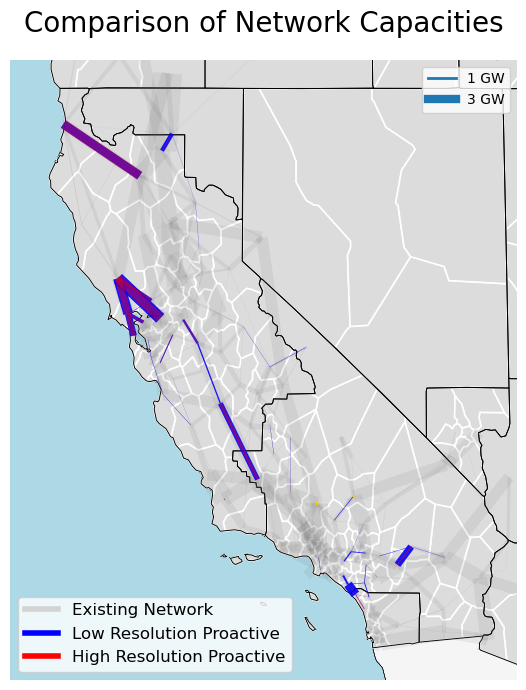

In [196]:
fig, axes = plt.subplots(1, 1, figsize=(7 , 7), subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})

line_scale = 5e2
bus_scale = 1e7

plot_network_capacity(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    plot_type='base',
    bus_scale = 1e10,
    line_scale= line_scale,
    line_colors="dimgrey", 
    link_colors="dimgrey",
    line_alpha=0.1,
) 

SQ_color = "blue"
ID_color = "red"

plot_network_capacity(
    n_lr_proactive,
    ax=axes,
    regions=regions,
    plot_type='new',
    bus_scale = bus_scale,
    line_scale= line_scale,
    line_colors=SQ_color, 
    link_colors=SQ_color,
    line_alpha=0.9,
) 

plot_network_capacity(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    plot_type='new',
    bus_scale = bus_scale,
    line_scale= line_scale,
    line_colors=ID_color, 
    link_colors=ID_color,
    line_alpha=0.4,
) 

pypsa.plot.add_legend_lines(axes, sizes=[1e3/line_scale, 3e3/line_scale], labels=["1 GW", "3 GW"])
legend_elements = [
    Line2D([0], [0], color='lightgrey', lw=4, label='Existing Network'),
    Line2D([0], [0], color=SQ_color, lw=4, label='Low Resolution Proactive'),
    Line2D([0], [0], color=ID_color, lw=4, label='High Resolution Proactive'),
]
axes.legend(handles=legend_elements, loc='lower left', fontsize=TITLE_SIZE * 0.6)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0.7,
)
# Set extent AFTER all plotting, and force it
bbox = [-125, -114, 32, 42.5]
axes.set_extent(bbox, crs=ccrs.PlateCarree())

plt.title("Comparison of Network Capacities", fontsize=TITLE_SIZE, pad=20)
fig.tight_layout()

# Multi-plot

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

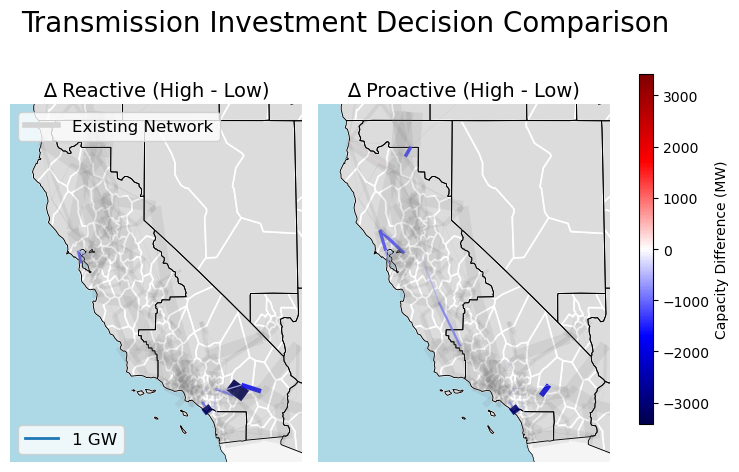

In [215]:
# Reactive differences
iq_diff_bus, iq_diff_line, iq_diff_link = get_diff_capacities(n_hr_reactive)
sq_diff_bus, sq_diff_line, sq_diff_link = get_diff_capacities(n_lr_reactive)
diff_bus_reactive = iq_diff_bus - sq_diff_bus
diff_line_reactive = iq_diff_line - sq_diff_line
diff_link_reactive = iq_diff_link - sq_diff_link

# Proactive differences
iq_diff_bus, iq_diff_line, iq_diff_link = get_diff_capacities(n_hr_proactive)
sq_diff_bus, sq_diff_line, sq_diff_link = get_diff_capacities(n_lr_proactive)
diff_bus_proactive = iq_diff_bus - sq_diff_bus
diff_line_proactive = iq_diff_line - sq_diff_line
diff_link_proactive = iq_diff_link - sq_diff_link

# Create a list of dictionaries for each subplot
subplot_data = [
    {
        'title': '∆ Reactive (High - Low)',
        'bus_values': diff_bus_reactive,
        'line_values': diff_line_reactive,
        'link_values': diff_link_reactive
    },
    {
        'title': '∆ Proactive (High - Low)',
        'bus_values': diff_bus_proactive,
        'line_values': diff_line_proactive, 
        'link_values': diff_link_proactive
    },
]


# Common parameters
line_colors = "purple"
link_colors = "purple"
line_alpha = 0.9
colormap = "seismic"
line_scale = 5e2
bus_scale = 1e10

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(7, 5), 
                         subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})
# Find the maximum absolute value across all data for consistent color scaling
vmax = max([
    max(abs(data['line_values'].min()), abs(data['line_values'].max())) 
    for data in subplot_data
]) * 0.5
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)


# Plot each subplot
for i, (ax, data) in enumerate(zip(axes, subplot_data)):
    # Plot capacity map
    plot_capacity_map(
        n=n_lr_reactive,
        bus_values=data['bus_values'],
        line_values=data['line_values'],
        link_values=data['link_values'],
        regions=regions,
        ax=ax,
        line_scale=line_scale,
        bus_scale=bus_scale,
        title=None,  # We'll set title separately
        line_colors=data['line_values'],
        line_cmap=colormap,
        link_colors=link_colors,
        line_alpha=line_alpha,
        line_norm=norm,  # Use the same norm for all subplots
        bus_split_circles=True
    )
    
    # Plot network base
    plot_network_capacity(
        n_lr_reactive,
        ax=ax,
        regions=regions,
        plot_type='base',
        bus_scale=10e20,
        line_scale=line_scale,
        line_colors="dimgrey",
        link_colors="dimgrey",
        line_alpha=0.1,
    )
    
    # Add region boundaries
    regions_lr.boundary.plot(
        ax=ax,
        facecolor=None,
        edgecolor="black",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=0.7,
    )
    
    # Set subplot title
    ax.set_title(data['title'], fontsize=TITLE_SIZE * 0.7)
    
    # Only add legend to the first subplot
    if i == 0:
        pypsa.plot.add_legend_lines(
            ax, 
            sizes=[1e3/line_scale], 
            labels=["1 GW"], legend_kw={"loc": "lower left", "fontsize": TITLE_SIZE * 0.6}
        )
        legend_elements = [
            Line2D([0], [0], color='lightgrey', lw=4, label='Existing Network'),
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=TITLE_SIZE * 0.6)


    # Set extent AFTER all plotting, and force it
    bbox = [-125, -114, 32, 42.5]
    ax.set_extent(bbox, crs=ccrs.PlateCarree())


# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm._A = []

# Add a colorbar that applies to all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label('Capacity Difference (MW)', fontsize=TITLE_SIZE * 0.5)

# Add main title
plt.suptitle("Transmission Investment Decision Comparison", fontsize=TITLE_SIZE)

# Adjust layout
fig.tight_layout(rect=[0, 0, 0.9, 0.95])  # Make room for colorbar

plt.show()

In [213]:
data = subplot_data[0]
max(abs(data['line_values'].min()), abs(data['line_values'].max())) 

6836.99010041311

# Plot generation capacities map

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

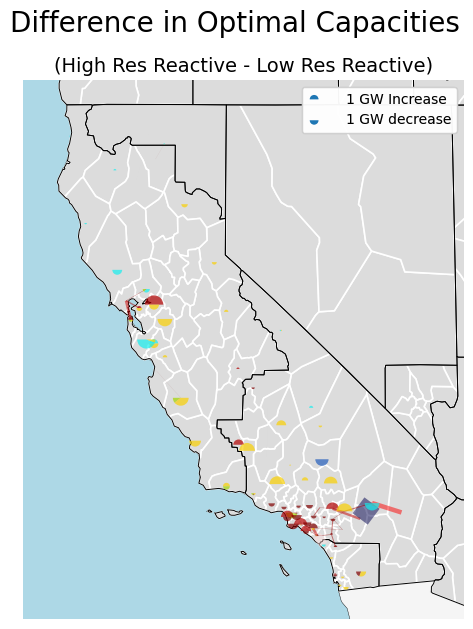

In [166]:
groupers = pypsa.statistics.groupers
def get_capacities(n: pypsa.Network):
    groupers = pypsa.statistics.groupers
    bus_capacities = n.statistics.optimal_capacity(groupby=groupers["bus", "carrier"], nice_names=False)
    bus_capacities = bus_capacities[bus_capacities.index.get_level_values('component') != 'Line']
    bus_capacities = bus_capacities.droplevel(0)
    bus_capacities = bus_capacities[n.investment_periods[0]]
    return bus_capacities

cap_id = get_capacities(n_hr_reactive)
cap_sq = get_capacities(n_lr_reactive)
diff_cap = cap_id - cap_sq

iq_diff_bus, iq_diff_line, iq_diff_link = get_diff_capacities(n_hr_reactive)
sq_diff_bus, sq_diff_line, sq_diff_link = get_diff_capacities(n_lr_reactive)

diff_line = iq_diff_line - sq_diff_line
diff_link = iq_diff_link - sq_diff_link

fig , axes = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})
# Plot data
bus_scale = 1e5

plot_capacity_map(
    n_lr_reactive,
    ax=axes,
    regions=regions,
    bus_values=diff_cap,
    link_values=diff_link,
    line_values=diff_line,
    bus_scale = 1e5,
    line_scale= line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=True,
    line_colors=diff_line,
    line_cmap=colormap,
)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0.7,
)

# Set extent AFTER all plotting, and force it
bbox = [-125, -114, 32, 42.5]
axes.set_extent(bbox, crs=ccrs.PlateCarree())


plt.suptitle("Difference in Optimal Capacities", fontsize=TITLE_SIZE)
plt.title("(High Res Reactive - Low Res Reactive)", fontsize=TITLE_SIZE * 0.7)

pypsa.plot.add_legend_semicircles(axes, sizes=[1e3/bus_scale, -1e3/bus_scale], labels=["1 GW Increase", "1 GW decrease"])

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

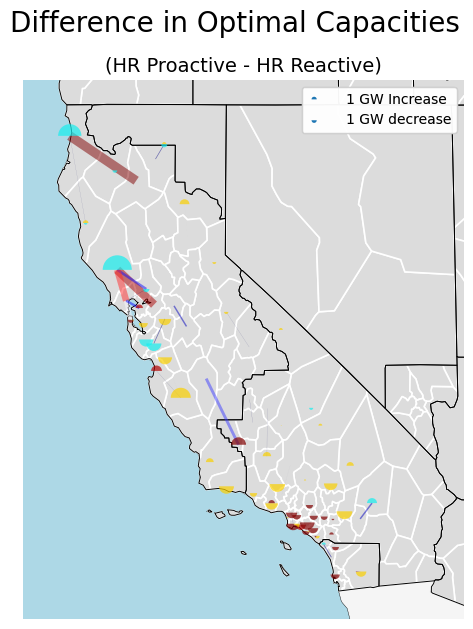

In [167]:
groupers = pypsa.statistics.groupers
def get_capacities(n: pypsa.Network):
    groupers = pypsa.statistics.groupers
    bus_capacities = n.statistics.optimal_capacity(groupby=groupers["bus", "carrier"], nice_names=False)
    bus_capacities = bus_capacities[bus_capacities.index.get_level_values('component') != 'Line']
    bus_capacities = bus_capacities.droplevel(0)
    bus_capacities = bus_capacities[n.investment_periods[0]]
    return bus_capacities

cap_id = get_capacities(n_hr_proactive)
cap_sq = get_capacities(n_hr_reactive)
diff_cap = cap_id - cap_sq

iq_diff_bus, iq_diff_line, iq_diff_link = get_diff_capacities(n_hr_proactive)
sq_diff_bus, sq_diff_line, sq_diff_link = get_diff_capacities(n_hr_reactive)

diff_line = iq_diff_line - sq_diff_line
diff_link = iq_diff_link - sq_diff_link

fig , axes = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})
# Plot data
bus_scale = 1e5

plot_capacity_map(
    n_hr_reactive,
    ax=axes,
    regions=regions,
    bus_values=diff_cap,
    link_values=diff_link,
    line_values=diff_line,
    bus_scale = 1e5,
    line_scale= line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=True,
    line_colors=diff_line,
    line_cmap=colormap,
)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0.7,
)

plt.suptitle("Difference in Optimal Capacities", fontsize=TITLE_SIZE)
plt.title("(HR Proactive - HR Reactive)", fontsize=TITLE_SIZE * 0.7)

pypsa.plot.add_legend_semicircles(axes, sizes=[1e3/bus_scale, -1e3/bus_scale], labels=["1 GW Increase", "1 GW decrease"])

# Set extent AFTER all plotting, and force it
bbox = [-125, -114, 32, 42.5]
axes.set_extent(bbox, crs=ccrs.PlateCarree())


/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

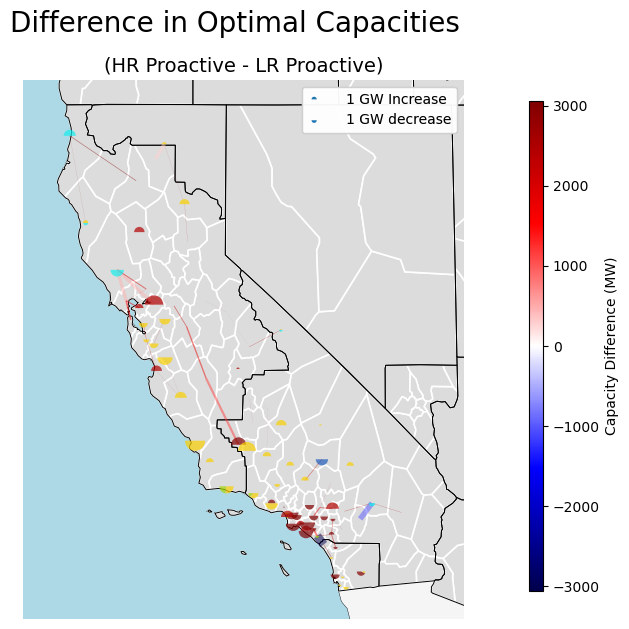

In [185]:
groupers = pypsa.statistics.groupers
def get_capacities(n: pypsa.Network):
    groupers = pypsa.statistics.groupers
    bus_capacities = n.statistics.optimal_capacity(groupby=groupers["bus", "carrier"], nice_names=False)
    bus_capacities = bus_capacities[bus_capacities.index.get_level_values('component') != 'Line']
    bus_capacities = bus_capacities.droplevel(0)
    bus_capacities = bus_capacities[n.investment_periods[0]]
    return bus_capacities

cap_id = get_capacities(n_hr_proactive)
cap_sq = get_capacities(n_lr_proactive)
diff_cap = cap_id - cap_sq

iq_diff_bus, iq_diff_line, iq_diff_link = get_diff_capacities(n_hr_proactive)
sq_diff_bus, sq_diff_line, sq_diff_link = get_diff_capacities(n_lr_proactive)

diff_line = iq_diff_line - sq_diff_line
diff_link = iq_diff_link - sq_diff_link

fig , axes = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})
# Plot data
bus_scale = 1e5
line_scale = 5e2

plot_capacity_map(
    n_lr_proactive,
    ax=axes,
    regions=regions,
    bus_values=diff_cap,
    link_values=diff_link,
    line_values=diff_line,
    bus_scale = 1e5,
    line_scale= line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=True,
    line_colors=diff_line,
    line_cmap=colormap,
)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0.7,
)

plt.suptitle("Difference in Optimal Capacities", fontsize=TITLE_SIZE)
plt.title("(HR Proactive - LR Proactive)", fontsize=TITLE_SIZE * 0.7)

pypsa.plot.add_legend_semicircles(axes, sizes=[1e3/bus_scale, -1e3/bus_scale], labels=["1 GW Increase", "1 GW decrease"])

# Set extent AFTER all plotting, and force it
bbox = [-125, -114, 32, 42.5]
axes.set_extent(bbox, crs=ccrs.PlateCarree())

# Find the maximum absolute value across all data for consistent color scaling
vmax = max(abs(diff_line.min()), abs(diff_line.max()))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm._A = []

# Add a colorbar that applies to all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label('Capacity Difference (MW)', fontsize=TITLE_SIZE * 0.5)


# Interregional vs intraregional

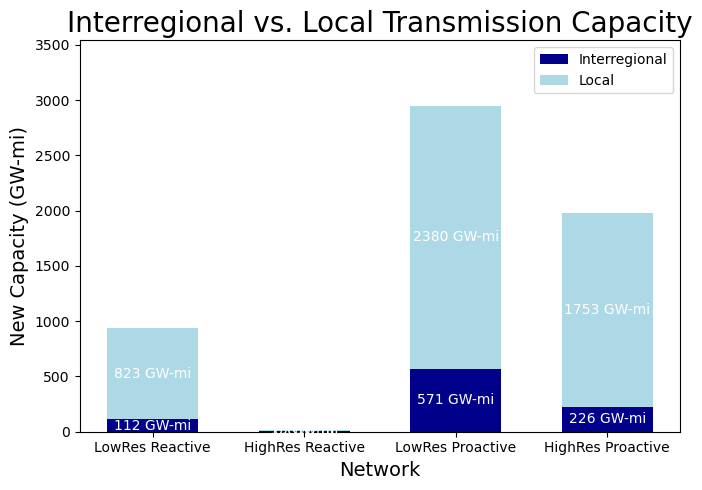

In [168]:
# Function to mark lines as interregional or intraregional
def mark_interregional_lines(network):
    network.lines['bus0_zone'] = network.lines['bus0'].map(lambda x: network.buses.loc[x, 'reeds_zone'])
    network.lines['bus1_zone'] = network.lines['bus1'].map(lambda x: network.buses.loc[x, 'reeds_zone'])
    network.lines['interregional'] = network.lines['bus0_zone'] != network.lines['bus1_zone']
    return network
# Mark interregional lines for each network
n_hr_reactive = mark_interregional_lines(n_hr_reactive)
n_lr_reactive = mark_interregional_lines(n_lr_reactive)
n_lr_proactive = mark_interregional_lines(n_lr_proactive)
n_hr_proactive = mark_interregional_lines(n_hr_proactive)


# Calculate the proportion of interregional vs. intraregional transmission capacity
def calculate_transmission_proportions(network):
    # Calculate new capacity for each line (only positive values)
    new_capacity = (network.lines.s_nom_opt - network.lines.s_nom).clip(lower=0)  / 1e3  # Convert to GW
    new_capacity_length = network.lines.length * new_capacity
    
    # Calculate total new capacity
    total_new_capacity = new_capacity_length.sum()
    
    # Calculate interregional and intraregional capacity
    interregional_capacity = new_capacity_length[network.lines.interregional].sum()
    intraregional_capacity = new_capacity_length[~network.lines.interregional].sum()
    
    return {
        'total_capacity': total_new_capacity,
        'interregional_capacity': interregional_capacity,
        'intraregional_capacity': intraregional_capacity
    }

# Calculate proportions for each network
lr_reactive_prop = calculate_transmission_proportions(n_lr_reactive)
hr_reactive_prop = calculate_transmission_proportions(n_hr_reactive)
lr_proactive_proportions = calculate_transmission_proportions(n_lr_proactive)
proactive_proportions = calculate_transmission_proportions(n_hr_proactive)

# Create the plot
fig, ax = plt.subplots(figsize=(7, 5))

# Set up the data
networks = ['LowRes Reactive', 'HighRes Reactive', 'LowRes Proactive' , 'HighRes Proactive']
interregional_caps = [lr_reactive_prop['interregional_capacity'], hr_reactive_prop['interregional_capacity'],lr_proactive_proportions['interregional_capacity'], proactive_proportions['interregional_capacity']]
intraregional_caps = [lr_reactive_prop['intraregional_capacity'], hr_reactive_prop['intraregional_capacity'],lr_proactive_proportions['intraregional_capacity'],proactive_proportions['intraregional_capacity']]
total_caps = [lr_reactive_prop['total_capacity'], hr_reactive_prop['total_capacity'],lr_proactive_proportions['total_capacity'], proactive_proportions['total_capacity']]

# Create the stacked bar plot
x = np.arange(len(networks))
width = 0.6

ax.bar(x, interregional_caps, width, label='Interregional', color='darkblue')
ax.bar(x, intraregional_caps, width, bottom=interregional_caps, label='Local', color='lightblue')

# Add labels and title
ax.set_xlabel('Network', fontsize=TITLE_SIZE * 0.7)
ax.set_ylabel('New Capacity (GW-mi)', fontsize=TITLE_SIZE * 0.7)
ax.set_title('Interregional vs. Local Transmission Capacity', fontsize=TITLE_SIZE)
ax.set_xticks(x)
ax.set_xticklabels(networks)
ax.legend(loc='upper right')

# Add text labels with absolute values
for i in range(len(networks)):
    # Text color based on background darkness
    interregional_color = intraregional_color = 'white'

    # Add absolute value labels
    ax.text(i, interregional_caps[i]/2, f'{interregional_caps[i]:.0f} GW-mi', 
             ha='center', va='center', fontsize=TITLE_SIZE * 0.5, color=interregional_color)
    ax.text(i, interregional_caps[i] + intraregional_caps[i]/2, f'{intraregional_caps[i]:.0f} GW-mi', 
             ha='center', va='center', fontsize=TITLE_SIZE * 0.5, color=intraregional_color)

# Set y-axis limit to make room for the total capacity text
y_max = max([interregional_caps[i] + intraregional_caps[i] for i in range(len(networks))]) * 1.2
ax.set_ylim(0, y_max)

plt.tight_layout()

# PPT Figures

In [169]:
n_lr = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/elec_s310_c33a_ec_lvopt_3h_E.nc')
lr_regions = gpd.read_file('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/caiso/lr_ca.geojson')

INFO:pypsa.io:Imported network elec_s310_c33a_ec_lvopt_3h_E.nc has buses, carriers, generators, lines, links, loads, storage_units


In [170]:
groupers = pypsa.statistics.groupers
def get_capacities(n: pypsa.Network, stat_type: str = "optimal_capacity"):
    groupers = pypsa.statistics.groupers
    # bus_capacities = n.statistics.optimal_capacity(groupby=groupers["bus", "carrier"], nice_names=False)
    bus_capacities = getattr(n.statistics, stat_type)(groupby=groupers["bus", "carrier"], nice_names=False)
    bus_capacities = bus_capacities[bus_capacities.index.get_level_values('component') != 'Line']
    bus_capacities = bus_capacities.droplevel(0)
    bus_capacities = bus_capacities[n.investment_periods[0]]
    return bus_capacities


## PLOT 1

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

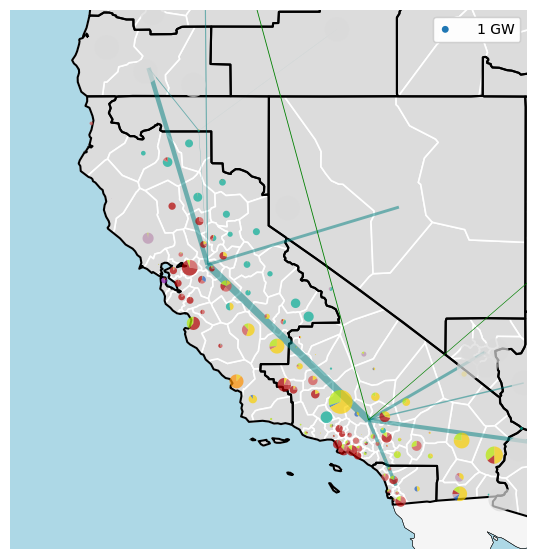

In [171]:
fig, axes = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.PlateCarree()})

# Plot your data first
bus_scale = 1e5
line_scale = 5e3
cap_id = get_capacities(n_lr)
iq_diff_bus, iq_diff_line, iq_diff_link = get_diff_capacities(n_hr_proactive)

plot_capacity_map(
    n_lr,
    ax=axes,
    regions=regions,
    bus_values=0,
    link_values=n_lr.links.p_nom,
    line_values=n_lr.lines.s_nom,
    bus_scale=bus_scale,
    line_scale=line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=True,
)

plot_capacity_map(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    bus_values=get_capacities(n_hr_proactive, stat_type="installed_capacity"),
    link_values=iq_diff_link * 0,
    line_values=iq_diff_line * 0,
    bus_scale=1e5,
    line_scale=line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=False,
)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=1.5,
)

# Set extent AFTER all plotting, and force it
bbox = [-126, -114, 31.5, 44]
axes.set_extent(bbox, crs=ccrs.PlateCarree())

plt.suptitle("", fontsize=TITLE_SIZE)
plt.title("", fontsize=TITLE_SIZE * 0.7)
pypsa.plot.add_legend_circles(axes, sizes=[1e3/bus_scale], labels=["1 GW"])

## PLOT 2

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



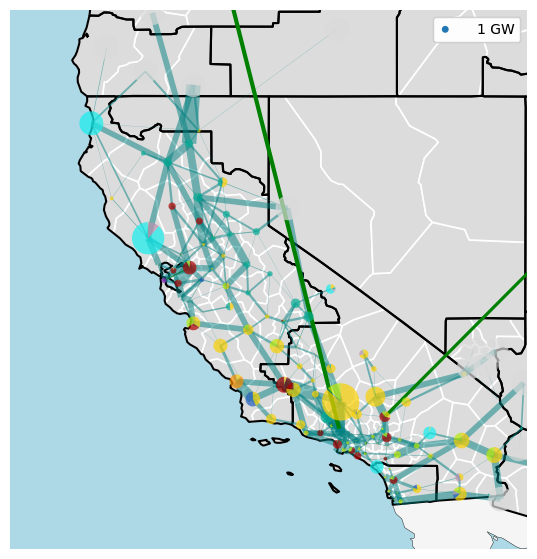

In [172]:
fig, axes = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.PlateCarree()})

# Plot data
bus_scale = 1e5
line_scale = 1e3

plot_capacity_map(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    bus_values= get_capacities(n_hr_proactive, stat_type="optimal_capacity"),
    link_values=n_hr_proactive.links.p_nom,
    line_values=n_hr_proactive.lines.s_nom,
    bus_scale = 1e5,
    line_scale= line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=False,
)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=1.5,
)

plt.suptitle("", fontsize=TITLE_SIZE)
plt.title("", fontsize=TITLE_SIZE * 0.7)

# Set extent AFTER all plotting, and force it
bbox = [-126, -114, 31.5, 44]
axes.set_extent(bbox, crs=ccrs.PlateCarree())


pypsa.plot.add_legend_circles(axes, sizes=[1e3/bus_scale], labels=["1 GW"])

## PLOT 3

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

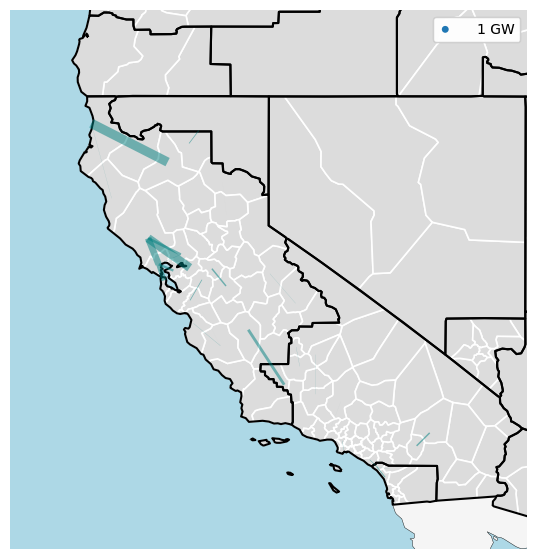

In [173]:
fig, axes = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.PlateCarree()})

bus_scale = 1e5
line_scale = 5e2

iq_diff_bus, iq_diff_line, iq_diff_link = get_diff_capacities(n_hr_proactive)

plot_capacity_map(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    bus_values= 0,
    link_values=iq_diff_link,
    line_values=iq_diff_line,
    bus_scale = 1e5,
    line_scale= line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=False,
)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=1.5,
)

plt.suptitle("", fontsize=TITLE_SIZE)
plt.title("", fontsize=TITLE_SIZE * 0.7)

# Set extent AFTER all plotting, and force it
bbox = [-126, -114, 31.5, 44]
axes.set_extent(bbox, crs=ccrs.PlateCarree())


pypsa.plot.add_legend_circles(axes, sizes=[1e3/bus_scale], labels=["1 GW"])